In [6]:
import geopandas as gpd
import pandas as pd

# Leer el shapefile
gdf = gpd.read_file("taxi_zones.shp")

# Calcular centroides usando métodos seguros
gdf["centroid"] = gdf.geometry.centroid
gdf["centroid_lon"] = gdf["centroid"].apply(lambda point: point.x)
gdf["centroid_lat"] = gdf["centroid"].apply(lambda point: point.y)

# Ver las primeras filas
print(gdf[["LocationID", "centroid_lat", "centroid_lon"]].head())

# Guardar como CSV para clustering si quieres
gdf[["LocationID", "centroid_lat", "centroid_lon"]].to_csv("zonas_con_centroides.csv", index=False)


   LocationID   centroid_lat  centroid_lon
0           1  191376.749531  9.359968e+05
1           2  164018.754403  1.031086e+06
2           3  254265.478659  1.026453e+06
3           4  202959.782391  9.906340e+05
4           5  140681.351376  9.318714e+05


    k        SSE  Silhouette
0   2  50.564395    0.529017
1   3  30.387163    0.433875
2   4  19.677688    0.427582
3   5  15.448119    0.367531
4   6  12.534799    0.349360
5   7  10.761853    0.337091
6   8   8.849401    0.369082
7   9   7.293477    0.387042
8  10   6.387948    0.381547


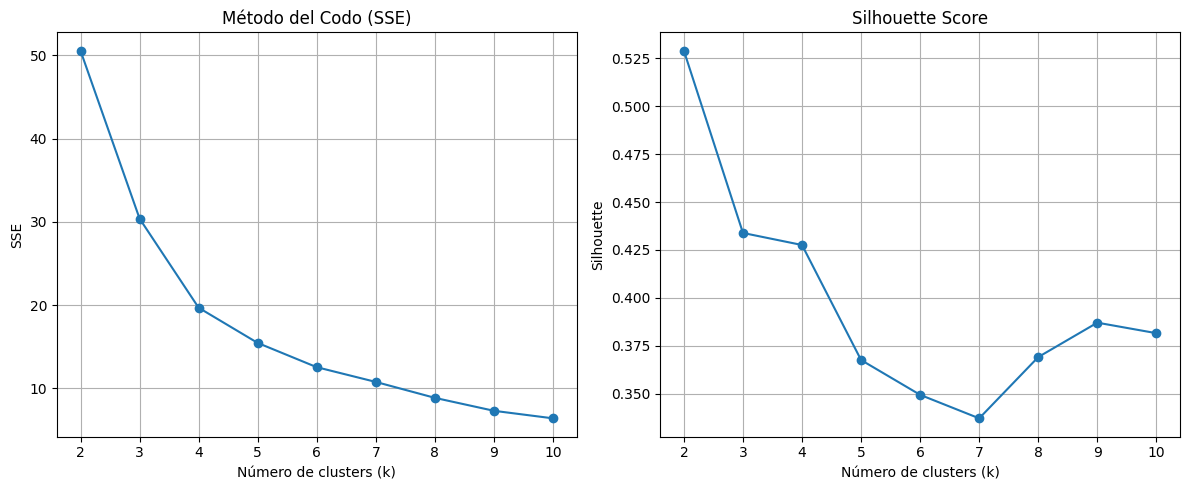


✔ k con mejor Silhouette: 2
≈ k sugerido por 'codo' (heurístico): 3


In [12]:
# --- Evaluación de número de macrozonas: Método del Codo + Silhouette ---
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1) Cargar coordenadas (usa el archivo que ya generaste)
df = pd.read_csv("manhattan_zonas_con_macrozona.csv")

# 2) Matriz de features (lat/lon de centroides); estandarizamos por seguridad
X = df[["centroid_lat", "centroid_lon"]].to_numpy()
X_std = StandardScaler().fit_transform(X)

# 3) Evaluar k desde 2 hasta 10
ks = range(2, 11)
sse = []                  # Inercia intra-cluster (para el codo)
sil_scores = []           # Silhouette Score

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_std)
    sse.append(km.inertia_)
    sil_scores.append(silhouette_score(X_std, labels))

# 4) Tabla resumen y guardado opcional
df_k = pd.DataFrame({"k": ks, "SSE": sse, "Silhouette": sil_scores})
print(df_k)
df_k.to_csv("evaluacion_k_manhattan.csv", index=False)

# 5) Gráficos (codo y silhouette)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(list(ks), sse, marker="o")
plt.title("Método del Codo (SSE)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("SSE")
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(list(ks), sil_scores, marker="o")
plt.title("Silhouette Score")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette")
plt.grid(True)

plt.tight_layout()
plt.show()

# 6) Sugerencias rápidas (opcionales)
k_mejor_sil = int(df_k.iloc[df_k["Silhouette"].idxmax()]["k"])
print(f"\n✔ k con mejor Silhouette: {k_mejor_sil}")

# Heurística simple de 'codo': razón de mejora relativa de SSE
improvement = np.r_[np.nan, np.diff(sse)] * -1
ratio = np.r_[np.nan, improvement[1:] / improvement[:-1]]  # cuánto cae la mejora
k_codo_aprox = int(df_k.loc[ratio.argmax()+1, "k"]) if np.isfinite(ratio[1:]).any() else k_mejor_sil
print(f"≈ k sugerido por 'codo' (heurístico): {k_codo_aprox}")


✔ Guardado: manhattan_zonas_k3k4.csv


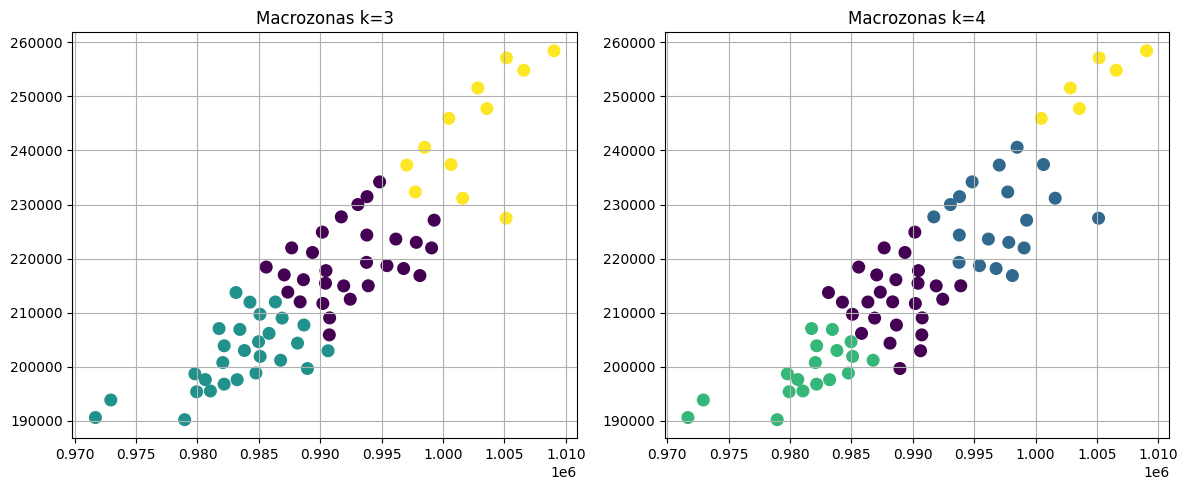

In [15]:
# === Clustering Manhattan: k=3 vs k=4 ===
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Lee los centroides de Manhattan (archivo que ya generaste)
df_z = pd.read_csv("manhattan_zonas_con_macrozona.csv")  # contiene LocationID, centroid_lat, centroid_lon

X = df_z[["centroid_lat", "centroid_lon"]].to_numpy()
X_std = StandardScaler().fit_transform(X)

# k=3
km3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_z["macrozona_k3"] = km3.fit_predict(X_std)

# k=4
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
df_z["macrozona_k4"] = km4.fit_predict(X_std)

# Guarda asignaciones
df_z[["LocationID","centroid_lat","centroid_lon","macrozona_k3","macrozona_k4"]].to_csv(
    "manhattan_zonas_k3k4.csv", index=False
)
print("✔ Guardado: manhattan_zonas_k3k4.csv")

# Visual rápido (opcional)
fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].scatter(df_z["centroid_lon"], df_z["centroid_lat"], c=df_z["macrozona_k3"], s=70)
axes[0].set_title("Macrozonas k=3"); axes[0].grid(True)

axes[1].scatter(df_z["centroid_lon"], df_z["centroid_lat"], c=df_z["macrozona_k4"], s=70)
axes[1].set_title("Macrozonas k=4"); axes[1].grid(True)

plt.tight_layout(); plt.show()


✔ Guardado: manhattan_zonas_con_macrozona_k4.csv (k=4)


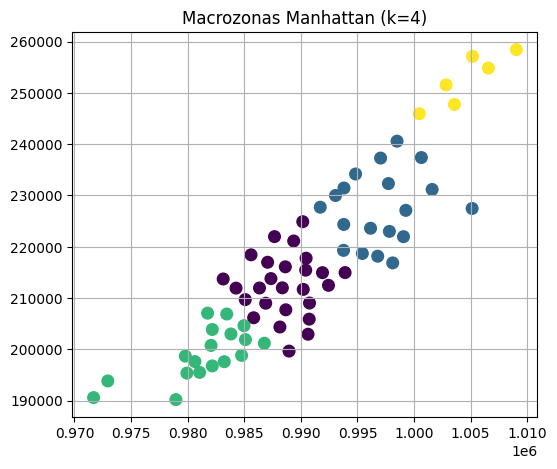

In [16]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Centroides que ya generaste antes
dfz = pd.read_csv("manhattan_zonas_con_macrozona.csv")  # LocationID, centroid_lat, centroid_lon

X = dfz[["centroid_lat","centroid_lon"]].to_numpy()
X_std = StandardScaler().fit_transform(X)

k = 4
km4 = KMeans(n_clusters=k, random_state=42, n_init=10)
dfz["macrozona"] = km4.fit_predict(X_std)

out_zonas = "manhattan_zonas_con_macrozona_k4.csv"
dfz.to_csv(out_zonas, index=False)
print(f"✔ Guardado: {out_zonas} (k=4)")

# Visual rápido
plt.figure(figsize=(6,5))
plt.scatter(dfz["centroid_lon"], dfz["centroid_lat"], c=dfz["macrozona"], s=70)
plt.title("Macrozonas Manhattan (k=4)")
plt.grid(True); plt.show()


In [17]:
import pandas as pd

PARQUET_VIAJES = "df_all_reducido_github.parquet"  # ajusta si corresponde
df_v = pd.read_parquet(PARQUET_VIAJES)

df_k4 = pd.read_csv("manhattan_zonas_con_macrozona_k4.csv").rename(columns={"LocationID":"PUlocationID"})

# Filtrar solo viajes donde origen y destino están en Manhattan (ids presentes en df_k4)
ids_m = df_k4["PUlocationID"].unique()
mask_mm = df_v["PUlocationID"].isin(ids_m) & df_v["DOlocationID"].isin(ids_m)
df_mm = df_v.loc[mask_mm, ["PUlocationID","DOlocationID"]].copy()

# Frecuencia por par OD
df_pairs = (df_mm.groupby(["PUlocationID","DOlocationID"])
                 .size().reset_index(name="n_viajes")
                 .sort_values("n_viajes", ascending=False))

# Pareto 80%
df_pairs["pct"] = df_pairs["n_viajes"] / df_pairs["n_viajes"].sum()
df_pairs["pct_acum"] = df_pairs["pct"].cumsum()
df_pairs["frecuente_80"] = df_pairs["pct_acum"] <= 0.80

# Adjuntar macrozonas origen/destino
df_mo = df_k4.rename(columns={"macrozona":"macrozona_origen"})[["PUlocationID","macrozona_origen"]]
df_md = df_k4.rename(columns={"PUlocationID":"DOlocationID","macrozona":"macrozona_destino"})[["DOlocationID","macrozona_destino"]]

df_pairs_k4 = (df_pairs.merge(df_mo, on="PUlocationID", how="left")
                       .merge(df_md, on="DOlocationID", how="left"))

out_pairs = "viajes_manhattan_macrozonas_filtrados_k4.csv"
df_pairs_k4.to_csv(out_pairs, index=False)
print(f"✔ Guardado: {out_pairs}  | filas: {len(df_pairs_k4):,}")



✔ Guardado: viajes_manhattan_macrozonas_filtrados_k4.csv  | filas: 3,793


In [18]:
import pandas as pd

df_pairs_k4 = pd.read_csv("viajes_manhattan_macrozonas_filtrados_k4.csv")

df_macro_flow = (df_pairs_k4.groupby(["macrozona_origen","macrozona_destino"])["n_viajes"]
                               .sum().reset_index()
                               .sort_values("n_viajes", ascending=False))

total = df_macro_flow["n_viajes"].sum()
df_macro_flow["pct_total"] = df_macro_flow["n_viajes"] / total
df_macro_flow["pct_acum"] = df_macro_flow["pct_total"].cumsum()
df_macro_flow["en_top80_macro"] = df_macro_flow["pct_acum"] <= 0.80

out_flows = "flujos_macro_macro_k4.csv"
df_macro_flow.to_csv(out_flows, index=False)
print(f"✔ Guardado: {out_flows}")
df_macro_flow.head(10)


✔ Guardado: flujos_macro_macro_k4.csv


,macrozona_origen,macrozona_destino,n_viajes,pct_total,pct_acum,en_top80_macro
0,0,0,104427,0.356187,0.356187,True
5,1,1,38101,0.129958,0.486145,True
1,0,1,36036,0.122914,0.609059,True
4,1,0,30504,0.104045,0.713105,True
8,2,0,28447,0.097029,0.810134,False
2,0,2,26721,0.091142,0.901276,False
10,2,2,16772,0.057207,0.958483,False
9,2,1,5048,0.017218,0.975701,False
6,1,2,3797,0.012951,0.988652,False
3,0,3,1325,0.004519,0.993171,False


In [19]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

dfz = pd.read_csv("manhattan_zonas_con_macrozona.csv")
X_std = StandardScaler().fit_transform(dfz[["centroid_lat","centroid_lon"]])

base = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_std)

rng_states = [0,1,2,3,4,10,21,42,99,123]
acc = []
for rs in rng_states:
    labs = KMeans(n_clusters=4, random_state=rs, n_init=10).fit_predict(X_std)
    # comparar up to permutation: usamos matriz de confusión y max matching
    from sklearn.metrics import confusion_matrix
    from itertools import permutations
    best = 0
    K = len(np.unique(base))
    for p in permutations(range(K)):
        mapped = np.array([p[l] for l in labs])
        best = max(best, (mapped == base).mean())
    acc.append(best)

print(f"Robustez k=4 (matching promedio): {np.mean(acc):.3f}  | min: {np.min(acc):.3f}  max: {np.max(acc):.3f}")


Robustez k=4 (matching promedio): 1.000  | min: 1.000  max: 1.000


In [20]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

# === PARÁMETROS ===
TOP_SHARE = 0.80              # súbelo a 0.90 si top-80 no genera arcos suficientes
FLOWS_CSV = "flujos_macro_macro_k4.csv"
SHAPEFILE = "taxi_zones.shp"  # ruta al shapefile TLC
ZONAS_K4  = "manhattan_zonas_con_macrozona_k4.csv"  # contiene LocationID y macrozona (k=4)

# === CARGA ===
df_flow = pd.read_csv(FLOWS_CSV)
df_zk4  = pd.read_csv(ZONAS_K4)  # LocationID, centroid_lat, centroid_lon, macrozona
gdf     = gpd.read_file(SHAPEFILE)[["LocationID","geometry"]]

# --- 1) VECINDAD POR FLUJOS (top-% macro) ---
df_flow = df_flow.sort_values("pct_acum")  # viene del paso 3
vecinas_dir = df_flow.loc[df_flow["pct_acum"] <= TOP_SHARE, ["macrozona_origen","macrozona_destino"]].drop_duplicates()

# versión no dirigida (A,B) con A<B
if not vecinas_dir.empty:
    v = vecinas_dir.copy()
    v["A"] = v[["macrozona_origen","macrozona_destino"]].min(axis=1)
    v["B"] = v[["macrozona_origen","macrozona_destino"]].max(axis=1)
    vecindad_flujo = v[["A","B"]].drop_duplicates().rename(columns={"A":"macrozona_A","B":"macrozona_B"})
else:
    vecindad_flujo = pd.DataFrame(columns=["macrozona_A","macrozona_B"])

# --- 2) VECINDAD GEOGRÁFICA (polígonos que se tocan) ---
# asignar macrozona a cada LocationID
gdf = gdf.merge(df_zk4[["LocationID","macrozona"]], on="LocationID", how="inner")
# disolver por macrozona para obtener un polígono por macrozona
gdf_m = gdf.dissolve(by="macrozona").reset_index()

# calcular toque (touches) entre macrozonas
touch_pairs = []
for i in range(len(gdf_m)):
    for j in range(i+1, len(gdf_m)):
        if gdf_m.loc[i, "geometry"].touches(gdf_m.loc[j, "geometry"]):
            touch_pairs.append((int(gdf_m.loc[i,"macrozona"]), int(gdf_m.loc[j,"macrozona"])))

vecindad_geo = pd.DataFrame(touch_pairs, columns=["macrozona_A","macrozona_B"])

# --- 3) UNIÓN DE VECINDADES (realista y estable) ---
vecindad_union = pd.concat([vecindad_flujo, vecindad_geo], ignore_index=True).drop_duplicates()

# --- 4) GUARDAR Y REPORTAR ---
out_flujo = "vecindad_macro_k4_flujo.csv"
out_geo   = "vecindad_macro_k4_geo.csv"
out_union = "vecindad_macro_k4_union.csv"
vecindad_flujo.to_csv(out_flujo, index=False)
vecindad_geo.to_csv(out_geo, index=False)
vecindad_union.to_csv(out_union, index=False)

print(f"✔ Vecindad por flujos  (≤{int(TOP_SHARE*100)}%): {len(vecindad_flujo)} pares -> {Path(out_flujo).resolve()}")
print(f"✔ Vecindad geográfica: {len(vecindad_geo)} pares -> {Path(out_geo).resolve()}")
print(f"✔ Vecindad UNIÓN:      {len(vecindad_union)} pares -> {Path(out_union).resolve()}")

# vista rápida (si existen)
print("\n— Muestra (flujos):")
print(vecindad_flujo.head(10))
print("\n— Muestra (geográfica):")
print(vecindad_geo.head(10))
print("\n— Muestra (unión):")
print(vecindad_union.head(10))


✔ Vecindad por flujos  (≤80%): 3 pares -> /content/vecindad_macro_k4_flujo.csv
✔ Vecindad geográfica: 0 pares -> /content/vecindad_macro_k4_geo.csv
✔ Vecindad UNIÓN:      3 pares -> /content/vecindad_macro_k4_union.csv

— Muestra (flujos):
   macrozona_A  macrozona_B
0            0            0
1            1            1
2            0            1

— Muestra (geográfica):
Empty DataFrame
Columns: [macrozona_A, macrozona_B]
Index: []

— Muestra (unión):
  macrozona_A macrozona_B
0           0           0
1           1           1
2           0           1


In [22]:
# Usa df_zonas, df_pairs, df_macro si ya existen. Si no, los carga desde disco.
import pandas as pd

try:
    df_zonas
except NameError:
    df_zonas = pd.read_csv("manhattan_zonas_con_macrozona_k4.csv")

try:
    df_pairs
except NameError:
    df_pairs = pd.read_csv("viajes_manhattan_macrozonas_filtrados_k4.csv")

try:
    df_macro
except NameError:
    df_macro = pd.read_csv("flujos_macro_macro_k4.csv")

# Vecindad unión (si existe)
try:
    df_vecindad
except NameError:
    try:
        df_vecindad = pd.read_csv("vecindad_macro_k4_union.csv")
    except FileNotFoundError:
        df_vecindad = pd.DataFrame(columns=["macrozona_A","macrozona_B"])


In [25]:
# === FIX: si el CSV no trae 'macrozona', la calculamos con k=4 y guardamos ===
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1) Cargar centroides (el archivo que SÍ tienes)
df_zonas = pd.read_csv("manhattan_zonas_con_macrozona_k4.csv")  # trae LocationID, centroid_lat, centroid_lon

# 2) Si falta 'macrozona', la generamos ahora con k=4
if "macrozona" not in df_zonas.columns:
    X = df_zonas[["centroid_lat","centroid_lon"]].to_numpy()
    X_std = StandardScaler().fit_transform(X)
    km = KMeans(n_clusters=4, random_state=42, n_init=10)
    df_zonas["macrozona"] = km.fit_predict(X_std)
    # (re)guardar con la columna nueva para que el resto de celdas funcionen
    df_zonas.to_csv("manhattan_zonas_con_macrozona_k4.csv", index=False)
    print("✔ 'macrozona' creada y guardada en manhattan_zonas_con_macrozona_k4.csv")
else:
    print("✔ 'macrozona' ya existe")

# 3) Cargar/recargar pares OD y macro-flujos (por si no están en memoria)
try:
    df_pairs
except NameError:
    df_pairs = pd.read_csv("viajes_manhattan_macrozonas_filtrados_k4.csv")

try:
    df_macro
except NameError:
    df_macro = pd.read_csv("flujos_macro_macro_k4.csv")

# 4) Vecindad (si existe)
try:
    df_vecindad
except NameError:
    try:
        df_vecindad = pd.read_csv("vecindad_macro_k4_union.csv")
    except FileNotFoundError:
        df_vecindad = pd.DataFrame(columns=["macrozona_A","macrozona_B"])

# 5) Chequeo final de columnas requeridas
required_z = {"LocationID","centroid_lat","centroid_lon","macrozona"}
missing = required_z - set(df_zonas.columns)
assert not missing, f"Faltan columnas en df_zonas: {missing}"
print("✅ df_zonas OK con macrozona k=4")



✔ 'macrozona' ya existe
✅ df_zonas OK con macrozona k=4


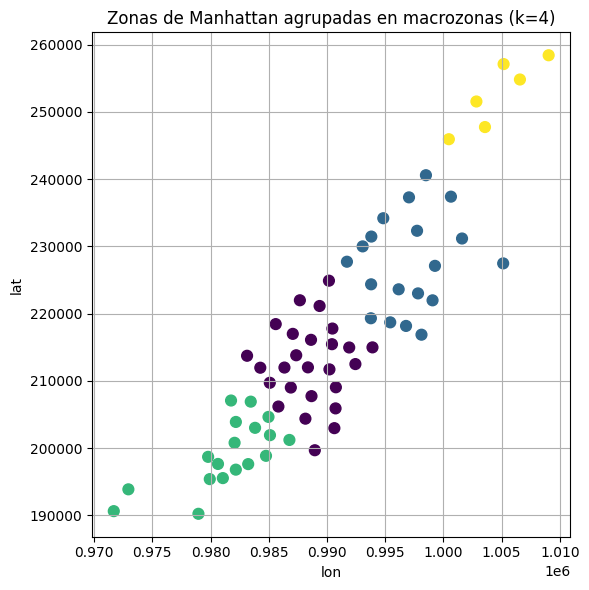

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(df_zonas["centroid_lon"], df_zonas["centroid_lat"], c=df_zonas["macrozona"], s=60)
plt.title("Zonas de Manhattan agrupadas en macrozonas (k=4)")
plt.xlabel("lon"); plt.ylabel("lat")
plt.grid(True)
plt.tight_layout()
plt.show()


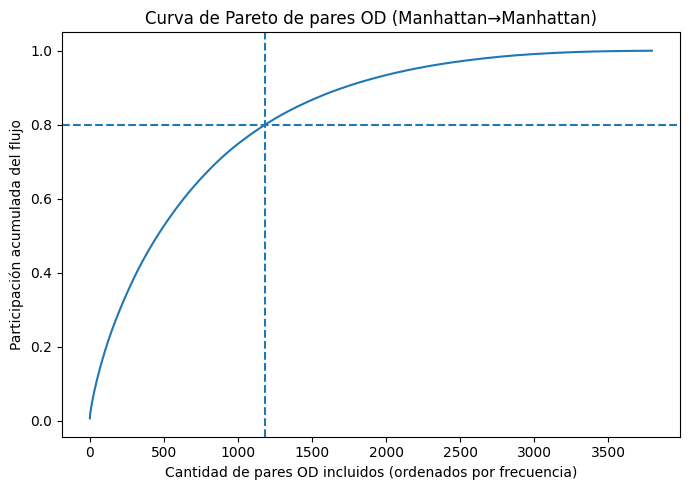

🔎 Pares OD necesarios para cubrir 80% del flujo: 1,183


In [27]:
import numpy as np
import matplotlib.pyplot as plt

freq_sorted = df_pairs.sort_values("n_viajes", ascending=False)["n_viajes"].to_numpy()
cum = np.cumsum(freq_sorted) / freq_sorted.sum()
x = np.arange(1, len(cum)+1)
idx80 = int(np.argmax(cum >= 0.80) + 1)

plt.figure(figsize=(7,5))
plt.plot(x, cum)
plt.axhline(0.80, linestyle="--")
plt.axvline(idx80, linestyle="--")
plt.title("Curva de Pareto de pares OD (Manhattan→Manhattan)")
plt.xlabel("Cantidad de pares OD incluidos (ordenados por frecuencia)")
plt.ylabel("Participación acumulada del flujo")
plt.tight_layout()
plt.show()

print(f"🔎 Pares OD necesarios para cubrir 80% del flujo: {idx80:,}")


In [37]:
import pandas as pd

# Asegura df_macro en memoria
try:
    df_macro
except NameError:
    df_macro = pd.read_csv("flujos_macro_macro_k4.csv")

rank = (df_macro
        .sort_values("n_viajes", ascending=False)
        .assign(arc=lambda d: d["macrozona_origen"].astype(str)+"→"+d["macrozona_destino"].astype(str),
                pct=lambda d: (d["pct_total"]*100).round(1),
                pct_acum=lambda d: (d["pct_acum"]*100).round(1))
        [["arc","n_viajes","pct","pct_acum","en_top80_macro"]])
rank.head(15)




,arc,n_viajes,pct,pct_acum,en_top80_macro
0,0→0,104427,35.6,35.6,True
1,1→1,38101,13.0,48.6,True
2,0→1,36036,12.3,60.9,True
3,1→0,30504,10.4,71.3,True
4,2→0,28447,9.7,81.0,False
5,0→2,26721,9.1,90.1,False
6,2→2,16772,5.7,95.8,False
7,2→1,5048,1.7,97.6,False
8,1→2,3797,1.3,98.9,False
9,0→3,1325,0.5,99.3,False


In [49]:
# Congelar df_macro correcto y evitar que se pise
assert {"macrozona_origen","macrozona_destino","n_viajes"} <= set(df_macro.columns)

df_macro0 = df_macro.copy()   # <- versión canónica
def get_df_macro():
    # siempre devuelve una copia limpia para cada figura/tablas
    return df_macro0.copy()

# Opcional: evita reusar el nombre df_macro en otras celdas
try:
    del df_macro
except NameError:
    pass

print("✅ df_macro0 congelado. Columnas:", list(df_macro0.columns))


✅ df_macro0 congelado. Columnas: ['macrozona_origen', 'macrozona_destino', 'n_viajes', 'pct_total', 'pct_acum', 'en_top80_macro']


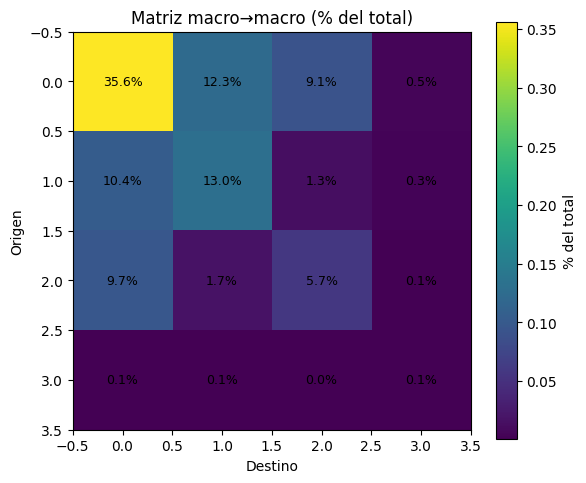

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

m = get_df_macro()
order = sorted(set(m["macrozona_origen"]) | set(m["macrozona_destino"]))

mat = (m.pivot(index="macrozona_origen", columns="macrozona_destino", values="pct_total")
        .reindex(index=order, columns=order)
        .fillna(0.0))

plt.figure(figsize=(6,5))
plt.imshow(mat.values, aspect="equal")
plt.title("Matriz macro→macro (% del total)")
plt.xlabel("Destino"); plt.ylabel("Origen")
plt.colorbar(label="% del total")

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        plt.text(j, i, f"{mat.values[i,j]*100:.1f}%", ha="center", va="center", fontsize=9)

plt.tight_layout(); plt.show()


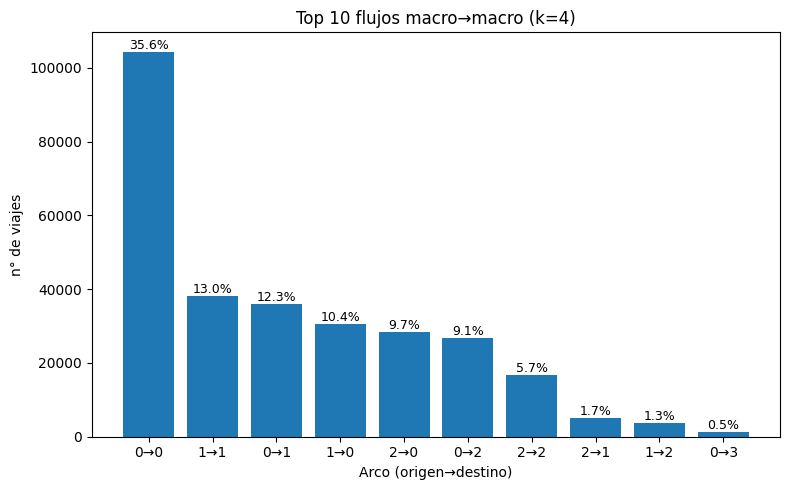

In [53]:
import matplotlib.pyplot as plt

m = get_df_macro()
top10 = (m.sort_values("n_viajes", ascending=False)
           .head(10)
           .assign(label=lambda d: d["macrozona_origen"].astype(str)+"→"+d["macrozona_destino"].astype(str),
                   pct_txt=lambda d: (d["pct_total"]*100).round(1).astype(str)+"%"))

plt.figure(figsize=(8,5))
plt.bar(top10["label"], top10["n_viajes"])
for i,(y,p) in enumerate(zip(top10["n_viajes"], top10["pct_txt"])):
    plt.text(i, y, p, ha="center", va="bottom", fontsize=9)
plt.title("Top 10 flujos macro→macro (k=4)")
plt.xlabel("Arco (origen→destino)"); plt.ylabel("n° de viajes")
plt.tight_layout(); plt.show()


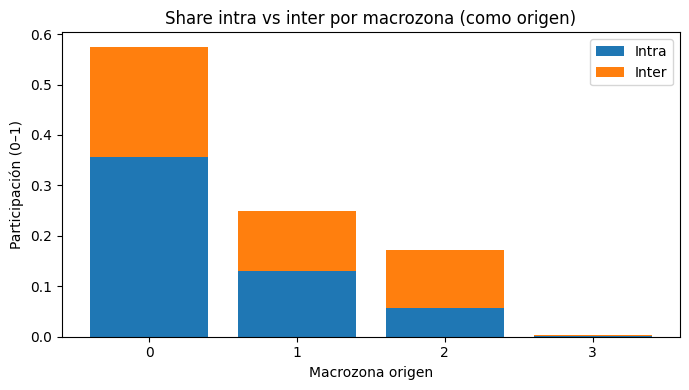

In [54]:
import matplotlib.pyplot as plt

m = get_df_macro()
df_intra = m[m["macrozona_origen"] == m["macrozona_destino"]]
df_inter = m[m["macrozona_origen"] != m["macrozona_destino"]]

intra_pct = df_intra.groupby("macrozona_origen")["pct_total"].sum()
inter_pct = df_inter.groupby("macrozona_origen")["pct_total"].sum()

order = sorted(set(m["macrozona_origen"]) | set(m["macrozona_destino"]))
intra_vals = [intra_pct.get(i,0) for i in order]
inter_vals = [inter_pct.get(i,0) for i in order]

plt.figure(figsize=(7,4))
plt.bar([str(i) for i in order], intra_vals, label="Intra")
plt.bar([str(i) for i in order], inter_vals, bottom=intra_vals, label="Inter")
plt.title("Share intra vs inter por macrozona (como origen)")
plt.xlabel("Macrozona origen"); plt.ylabel("Participación (0–1)")
plt.legend()
plt.tight_layout(); plt.show()


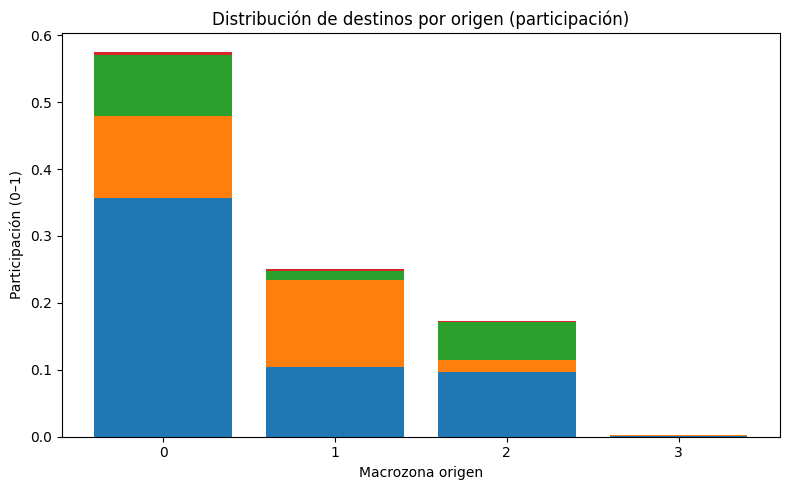

In [55]:
import numpy as np
import matplotlib.pyplot as plt

m = get_df_macro()
order = sorted(set(m["macrozona_origen"]) | set(m["macrozona_destino"]))
tab = (m.pivot(index="macrozona_origen", columns="macrozona_destino", values="pct_total")
        .reindex(index=order, columns=order)
        .fillna(0.0))

plt.figure(figsize=(8,5))
bottom = np.zeros(len(tab))
for dest in tab.columns:
    vals = tab[dest].values
    plt.bar(tab.index.astype(str), vals, bottom=bottom)
    bottom += vals

plt.title("Distribución de destinos por origen (participación)")
plt.xlabel("Macrozona origen"); plt.ylabel("Participación (0–1)")
plt.tight_layout(); plt.show()
